# 07 — Pre-Training RQwen3

---

## What Are We Doing Here?

Right now our RQwen3 has **properly initialized but random weights**. It outputs gibberish:

```
slidمعالجةפוטacedصب갔/apisliked渤咣 valued
```

**Pre-training** is Stage 1 of turning random noise into a language model.
We feed it raw text and ask: *"what token comes next?"* — billions of times.

### The 3 Stages of Training a Modern LLM

| Stage | Name | What It Does | This Notebook? |
|-------|------|-------------|----------------|
| **1. Pre-training** | Causal Language Modeling | Learns language from raw text | **YES** |
| 2. SFT | Supervised Fine-Tuning | Learns to follow instructions | No (notebook 06) |
| 3. RLHF / DPO | Alignment | Learns human preferences | No (future) |

---

## The 4 Things You Need for Training

Before we write any training code, you need to understand the 4 essential pieces.
Everything in our `src/` package was built to provide these:

### 1. Loss Function (`compute_loss`)
**What it is:** A number that tells you *how wrong* the model's predictions were.

For language models, we use **cross-entropy loss**. At every position in a sequence,
the model outputs a probability distribution over all 151,936 tokens. Cross-entropy
measures how far that distribution is from the correct answer (a one-hot vector at
the true next token).

```
Model predicts: {"the": 0.3, "cat": 0.1, "dog": 0.05, ...151,933 other tokens...}
Correct answer: "cat"  (probability should be 1.0)
Cross-entropy:  -log(0.1) = 2.3  (lower = better)
```

**Key numbers to remember:**
- **~11.9** = random guessing (ln(151,936)) — the model has zero knowledge
- **~8-9** = learned token frequencies ("the" is more common than "xylophone")
- **~5-6** = grammar is forming (knows nouns follow adjectives)
- **~3-4** = real language understanding

### 2. Optimizer (`create_optimizer`)
**What it is:** The algorithm that actually *updates the weights* based on gradients.

We use **AdamW** — the standard for transformers. It does two smart things:
- **Adaptive learning rates**: Parameters that haven't been updated much get bigger
  steps. Parameters that change a lot get smaller steps. This is way better than
  giving every parameter the same learning rate.
- **Weight decay**: Gently pushes weights toward zero to prevent overfitting.
  But NOT all weights — norm weights and biases are exempt because decaying them
  hurts training.

### 3. Learning Rate Scheduler (`create_scheduler`)
**What it is:** Controls how the learning rate changes over time.

We use a **cosine schedule with linear warmup**:

```
Learning Rate
     ↑
peak |      /‾‾‾‾‾‾‾‾\                    ← cosine decay
     |     /            \                     (gradual refinement)
     |    /               \
     |   /                  \
  0  |__/                     \___
     +--|-------|------------|----→ Steps
     0  warmup  peak        end
        ↑
        linear warmup
        (don't blow up random weights)
```

**Why warmup?** At step 0, weights are random. Big learning rates would send them
flying in random directions. Warmup lets things stabilize first.

**Why cosine decay?** Early in training, we want aggressive updates. Later, the model
is close to good and we want to fine-tune carefully with smaller steps.

### 4. Validation / Evaluation (`evaluate`)
**What it is:** Running the model on data it has **never seen during training**.

This is how you know if the model is actually *learning* vs. just *memorizing*:

| Training Loss | Validation Loss | What's Happening |
|:---:|:---:|---|
| ↓ Going down | ↓ Going down | Real learning — the model generalizes |
| ↓ Going down | ↑ Going UP | **Overfitting** — memorizing training data |
| → Flat | → Flat | Training stalled — LR too low or model saturated |
| ↑ Going up | ↑ Going up | Training diverged — LR too high, something is broken |

---

## How These 4 Pieces Fit Together

```
                     tokens (input_ids)
                            │
                    ┌───────▼───────┐
                    │   RQwen3      │
                    │  (forward)    │
                    └───────┬───────┘
                            │ logits (predictions)
                            ▼
            ┌───────────────────────────────┐
            │  ① compute_loss(logits, labels)│  ← "how wrong were we?"
            └───────────────┬───────────────┘
                            │ loss (scalar)
                            ▼
                    loss.backward()            ← compute gradients
                            │
                            ▼
            ┌───────────────────────────────┐
            │  ② optimizer.step()            │  ← nudge weights
            └───────────────┬───────────────┘
                            │
                            ▼
            ┌───────────────────────────────┐
            │  ③ scheduler.step()            │  ← adjust learning rate
            └───────────────┬───────────────┘
                            │
                            ▼
                   Repeat 10,000 times
                            │
                            ▼
            ┌───────────────────────────────┐
            │  ④ evaluate(model, val_data)   │  ← "is it actually learning?"
            └───────────────────────────────┘
```

---
# Initial Steps

## Imports & Path Management

In [1]:
import sys
sys.path.insert(0, '..')  # Add parent directory to sys.path to import src (My Package)

In [2]:
import os
import time
import math
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from transformers import AutoTokenizer
from IPython.display import Markdown

# Everything we need from our package
from src import (
    # Model
    CoreConfig, RQwen3, get_device, format_param_count, print_model_summary,
    # Data
    StreamingTokenDataset,
    # Training (the 4 essential pieces + utilities)
    TrainConfig, create_optimizer, create_scheduler, compute_loss, evaluate,
    save_checkpoint, load_checkpoint, save_snapshot, generate_sample,
)

## Configurations

In [3]:
DEVICE = get_device()
SAMPLE_PROMPT = 'The most important thing about mathematics is'

# --- Auto-scale for your hardware ---
train_cfg = TrainConfig()

if str(DEVICE) == 'mps':
    # Mac (Apple Silicon) — limited memory, run a quick test
    train_cfg.batch_size = 1
    train_cfg.seq_len = 512
    train_cfg.grad_accum_steps = 32
    train_cfg.max_steps = 200
    train_cfg.save_every = 100
    train_cfg.sample_every = 50
    train_cfg.warmup_steps = 20
    print('MPS detected -> Mac-friendly settings (batch=1, seq=512, 200 steps)')
elif str(DEVICE) == 'cuda':
    print('CUDA detected -> full training settings')
else:
    train_cfg.batch_size = 1
    train_cfg.seq_len = 256
    train_cfg.grad_accum_steps = 16
    train_cfg.max_steps = 50
    train_cfg.warmup_steps = 5
    print('CPU detected -> minimal settings for testing only')

# Effective batch size and total tokens
tokens_per_step = train_cfg.batch_size * train_cfg.grad_accum_steps * train_cfg.seq_len
total_tokens = tokens_per_step * train_cfg.max_steps

print(f'Device: {DEVICE}')
print(f'seq_len: {train_cfg.seq_len} | batch_size: {train_cfg.batch_size} | grad_accum: {train_cfg.grad_accum_steps}')
print(f'Effective batch: {train_cfg.batch_size * train_cfg.grad_accum_steps} sequences = {tokens_per_step:,} tokens/step')
print(f'Total tokens over {train_cfg.max_steps:,} steps: {format_param_count(total_tokens)}')

MPS detected -> Mac-friendly settings (batch=1, seq=512, 200 steps)
Device: mps
seq_len: 512 | batch_size: 1 | grad_accum: 32
Effective batch: 32 sequences = 16,384 tokens/step
Total tokens over 200 steps: 3M


---
# Model Setup

> We create the model, then use `create_optimizer` and `create_scheduler` from our
> package. These are the same functions that would be used if we trained on a bigger
> GPU cluster — the package makes them reusable.

In [4]:
# 1. Create model (weights are initialized by self.apply(self._init_weights))
model_config = CoreConfig()
model = RQwen3(model_config).to(DEVICE)
print_model_summary(model)
print()

# 2. Create optimizer (AdamW with proper weight-decay groups)
optimizer = create_optimizer(model, train_cfg)
print(f'Optimizer: AdamW (lr={train_cfg.learning_rate}, weight_decay={train_cfg.weight_decay})')

# 3. Create scheduler (cosine warmup)
scheduler = create_scheduler(optimizer, train_cfg)
print(f'Scheduler: cosine with {train_cfg.warmup_steps} warmup steps')

Total parameters: 507,940,352
Trainable parameters: 507,940,352
Model type: RQwen3

Optimizer: AdamW (lr=0.0003, weight_decay=0.1)
Scheduler: cosine with 20 warmup steps


### What `create_optimizer` Actually Does

Not all parameters should be treated the same. `create_optimizer` splits them into two groups:

| Group | Which Params | Weight Decay? | Why |
|-------|-------------|:---:|---|
| **Decay** | Attention projections, FFN layers (2D+ matrices) | Yes (0.1) | These are the bulk of the model. Decay prevents them from growing too large (overfitting). |
| **No decay** | RMSNorm weights, biases (1D params) | No (0.0) | These are tiny scaling factors. Decaying them pushes them toward zero, which hurts normalization. |

You can inspect this yourself:

In [6]:
# Peek at what the optimizer groups look like
for i, group in enumerate(optimizer.param_groups):
    n_params = sum(p.numel() for p in group['params'])
    print(f'Group {i}: {n_params:>12,} params | weight_decay={group["weight_decay"]} | lr={group["lr"]}')

Group 0:  507,904,000 params | weight_decay=0.1 | lr=0.0
Group 1:       36,352 params | weight_decay=0.0 | lr=0.0


---
# Data Pipeline

> We use `StreamingTokenDataset` from our package. It streams from HuggingFace,
> tokenizes on the fly, and yields `(input_ids, labels)` pairs ready for training.

### How Raw Text Becomes Training Data

```
Raw text: "Parents are usually the first to recognize that their child has a problem..."
    │
    │  Tokenizer (Qwen3 BPE, 151,936 vocab)
    ▼
Token IDs: [19281, 527, 6118, 279, 1156, 311, 15641, 430, 862, 1716, 702, ...]
    │
    │  Chunk into fixed-length sequences (seq_len tokens)
    ▼
input_ids: [19281, 527, 6118, 279, 1156, 311, ...]   ← tokens 0 to N-1
labels:    [  527, 6118, 279, 1156, 311, 15641, ...]  ← tokens 1 to N  (shifted by 1)
```

At every position, the model's job is to predict the **next** token.
Documents are separated by EOS tokens so the model learns document boundaries.

In [7]:
tokenizer = AutoTokenizer.from_pretrained('Qwen/Qwen3-1.7B')

# Training data
train_dataset = StreamingTokenDataset(train_cfg.dataset_name, tokenizer, train_cfg.seq_len)
train_loader  = DataLoader(train_dataset, batch_size=train_cfg.batch_size)

# Quick sanity check: grab one batch and verify shapes
test_batch = next(iter(train_loader))
print(f'input_ids shape: {test_batch[0].shape}  (batch, seq_len)')
print(f'labels shape:    {test_batch[1].shape}  (batch, seq_len)')
print(f'\nSample text: "{tokenizer.decode(test_batch[0][0][:30])}"')
print('\nData pipeline works.')

Resolving data files:   0%|          | 0/2410 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/2410 [00:00<?, ?it/s]

input_ids shape: torch.Size([1, 512])  (batch, seq_len)
labels shape:    torch.Size([1, 512])  (batch, seq_len)

Sample text: "No. 24; Updated March 2011
Click here to download and print a PDF version of this document.
Parents are usually"

Data pipeline works.


---
# Verify: Loss Function, Forward Pass, Backward Pass

> Before running the full training loop, let's test each piece individually.
> This is good practice — if something breaks, you know exactly where.

In [8]:
# Grab a single batch
input_ids, labels = test_batch
input_ids = input_ids.to(DEVICE)
labels = labels.to(DEVICE)

# --- Step 1: Forward pass ---
logits = model(input_ids)
print(f'1. Forward pass:')
print(f'   Input:  {input_ids.shape}     (batch, seq_len) — integer token IDs')
print(f'   Output: {logits.shape}  (batch, seq_len, vocab_size) — score for every token at every position')
print()

# --- Step 2: Compute loss ---
loss = compute_loss(logits, labels)
random_baseline = math.log(model_config.vocab_size)  # ln(151,936) ≈ 11.93
print(f'2. Loss: {loss.item():.4f}')
print(f'   Random baseline: {random_baseline:.4f}  (ln(vocab_size))')
print(f'   Our loss is {"close to" if abs(loss.item() - random_baseline) < 1 else "far from"} random — '
      f'{"expected for untrained model!" if abs(loss.item() - random_baseline) < 1 else "something may be off"}')
print()

# --- Step 3: Backward pass ---
loss.backward()
# Check that gradients actually flowed to the first layer
first_grad = model.embedding_layer.weight.grad
print(f'3. Backward pass:')
print(f'   Embedding grad shape: {first_grad.shape}')
print(f'   Embedding grad norm:  {first_grad.norm().item():.4f}  (>0 means gradients are flowing)')
print()

# --- Step 4: Optimizer step ---
old_weight = model.embedding_layer.weight[0, :5].clone().detach()
optimizer.step()
scheduler.step()
optimizer.zero_grad()
new_weight = model.embedding_layer.weight[0, :5].clone().detach()
print(f'4. Optimizer step:')
print(f'   Embedding[0][:5] before: {old_weight.cpu().numpy()}')
print(f'   Embedding[0][:5] after:  {new_weight.cpu().numpy()}')
print(f'   Weights changed: {not torch.equal(old_weight, new_weight)}')
print()
print('All 4 pieces are working. Ready to train.')

1. Forward pass:
   Input:  torch.Size([1, 512])     (batch, seq_len) — integer token IDs
   Output: torch.Size([1, 512, 151936])  (batch, seq_len, vocab_size) — score for every token at every position

2. Loss: 11.9317
   Random baseline: 11.9312  (ln(vocab_size))
   Our loss is close to random — expected for untrained model!

3. Backward pass:
   Embedding grad shape: torch.Size([151936, 512])
   Embedding grad norm:  0.1036  (>0 means gradients are flowing)

4. Optimizer step:
   Embedding[0][:5] before: [-0.01929403 -0.0227285   0.00774919 -0.08159012  0.16755325]
   Embedding[0][:5] after:  [-0.01929403 -0.0227285   0.00774919 -0.08159012  0.16755325]
   Weights changed: False

All 4 pieces are working. Ready to train.


---
# Pre-Training Loop

### What Happens Each Step

```
For each optimizer step:
│
├── Repeat `grad_accum_steps` times (accumulate gradients):
│   ├── Get a micro-batch of tokens
│   ├── Forward pass  → logits
│   ├── compute_loss  → scalar loss
│   └── loss.backward → gradients accumulate
│
├── Clip gradients (prevent explosion)
├── optimizer.step()  (update weights)
├── scheduler.step()  (adjust learning rate)
└── optimizer.zero_grad() (reset for next step)
```

### Gradient Accumulation

We want a large effective batch (32 sequences) for stable gradients, but we can't
fit 32 in GPU memory at once. Solution: process small micro-batches and add up
the gradients before updating.

```
Micro-batch 1: forward + backward (gradients stored, no weight update)
Micro-batch 2: forward + backward (gradients added to stored ones)
...
Micro-batch N: forward + backward (gradients added)
→ Now clip, optimizer step, zero gradients, repeat
```

> **To stop early:** Interrupt the kernel. Checkpoint auto-saves.
> **To resume:** Set `RESUME_FROM` below to the checkpoint path.

In [9]:
# Re-initialize everything fresh for the actual training run
# (the verify cell above used 1 optimizer step, so we start clean)

model = RQwen3(model_config).to(DEVICE)
optimizer = create_optimizer(model, train_cfg)
scheduler = create_scheduler(optimizer, train_cfg)

# Set to a checkpoint path to resume, or None to start fresh
RESUME_FROM = None  # e.g. '../checkpoints/step_100.pt'

if RESUME_FROM and os.path.exists(RESUME_FROM):
    start_step, loss_history = load_checkpoint(RESUME_FROM, model, optimizer, scheduler)
else:
    start_step = 0
    loss_history = []

os.makedirs(train_cfg.checkpoint_dir, exist_ok=True)
os.makedirs(train_cfg.snapshot_dir, exist_ok=True)

# Save untrained snapshot for later comparison
save_snapshot(model, 'pre-train-start', train_cfg.snapshot_dir)

print(f'Model ready. Starting from step {start_step}.')

Model ready. Starting from step 0.


In [10]:
# --- Training Loop ---
model.train()
optimizer.zero_grad()

data_iter = iter(train_loader)
accum_loss = 0.0
t_start = time.time()

print(f'Training: {train_cfg.max_steps:,} optimizer steps')
print(f'Effective batch: {train_cfg.batch_size} x {train_cfg.grad_accum_steps} = '
      f'{train_cfg.batch_size * train_cfg.grad_accum_steps} sequences ({tokens_per_step:,} tokens/step)')
print()

try:
    for opt_step in range(start_step, train_cfg.max_steps):

        # --- Accumulate gradients over micro-batches ---
        for micro in range(train_cfg.grad_accum_steps):
            try:
                input_ids, labels = next(data_iter)
            except StopIteration:
                data_iter = iter(train_loader)
                input_ids, labels = next(data_iter)

            input_ids = input_ids.to(DEVICE)
            labels = labels.to(DEVICE)

            logits = model(input_ids)
            loss = compute_loss(logits, labels)
            loss = loss / train_cfg.grad_accum_steps  # scale for accumulation
            loss.backward()
            accum_loss += loss.item()

        # --- Optimizer step ---
        torch.nn.utils.clip_grad_norm_(model.parameters(), train_cfg.max_grad_norm)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

        loss_history.append(accum_loss)
        accum_loss = 0.0

        # --- Logging ---
        if (opt_step + 1) % train_cfg.log_every == 0:
            elapsed = time.time() - t_start
            tokens_so_far = (opt_step + 1) * tokens_per_step
            tokens_per_sec = tokens_so_far / elapsed
            lr = scheduler.get_last_lr()[0]
            avg_loss = np.mean(loss_history[-train_cfg.log_every:])
            print(f'Step {opt_step+1:>6d}/{train_cfg.max_steps} | '
                  f'loss={avg_loss:.4f} | lr={lr:.2e} | '
                  f'{tokens_per_sec:,.0f} tok/s | '
                  f'{format_param_count(tokens_so_far)} tokens')

        # --- Sample generation ---
        if (opt_step + 1) % train_cfg.sample_every == 0:
            sample = generate_sample(model, tokenizer, SAMPLE_PROMPT)
            print(f'  Sample: "{sample[:120]}..."')
            model.train()

        # --- Checkpoint ---
        if (opt_step + 1) % train_cfg.save_every == 0:
            ckpt_path = os.path.join(train_cfg.checkpoint_dir, f'step_{opt_step+1}.pt')
            save_checkpoint(model, optimizer, scheduler, opt_step + 1, loss_history, ckpt_path)
            save_snapshot(model, f'step_{opt_step+1}', train_cfg.snapshot_dir)

except KeyboardInterrupt:
    print(f'\nInterrupted at step {opt_step + 1}.')
    ckpt_path = os.path.join(train_cfg.checkpoint_dir, f'step_{opt_step+1}_interrupted.pt')
    save_checkpoint(model, optimizer, scheduler, opt_step + 1, loss_history, ckpt_path)
    print('Checkpoint saved. Set RESUME_FROM to this path to continue.')

else:
    # Training completed normally
    ckpt_path = os.path.join(train_cfg.checkpoint_dir, f'step_{train_cfg.max_steps}_final.pt')
    save_checkpoint(model, optimizer, scheduler, train_cfg.max_steps, loss_history, ckpt_path)
    save_snapshot(model, 'pre-trained', train_cfg.snapshot_dir)
    print(f'\nTraining complete! Final checkpoint: {ckpt_path}')

elapsed_total = time.time() - t_start
print(f'Total time: {elapsed_total/60:.1f} minutes')

Training: 200 optimizer steps
Effective batch: 1 x 32 = 32 sequences (16,384 tokens/step)



Resolving data files:   0%|          | 0/2410 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/2410 [00:00<?, ?it/s]

Step     10/200 | loss=11.8127 | lr=1.50e-04 | 371 tok/s | 164K tokens
Step     20/200 | loss=11.0275 | lr=3.00e-04 | 358 tok/s | 328K tokens
Step     30/200 | loss=9.6608 | lr=2.98e-04 | 350 tok/s | 492K tokens
Step     40/200 | loss=8.5502 | lr=2.91e-04 | 338 tok/s | 655K tokens
Step     50/200 | loss=7.9688 | lr=2.80e-04 | 328 tok/s | 819K tokens
  Sample: "The most important thing about mathematics is,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,..."
Step     60/200 | loss=7.7327 | lr=2.65e-04 | 318 tok/s | 983K tokens
Step     70/200 | loss=7.8022 | lr=2.46e-04 | 80 tok/s | 1M tokens
Step     80/200 | loss=7.7100 | lr=2.25e-04 | 89 tok/s | 1M tokens
Step     90/200 | loss=7.7667 | lr=2.01e-04 | 97 tok/s | 1M tokens
Step    100/200 | loss=7.7246 | lr=1.76e-04 | 105 tok/s | 2M tokens
  Sample: "The most important thing about mathematics is the the the the the the the the the the the the the the the the the the th..."
  Checkpoint saved: ../checkpoints/step_100.pt
Step 

---
# Training Progress

### How to Read the Loss Curve

The loss tells you how *surprised* the model is by the correct answer:

| Loss | What It Means |
|------|---------------|
| ~11.9 | Random guessing — all 151,936 tokens equally likely |
| ~8-9 | Learned token frequencies ("the" > "xylophone") |
| ~5-6 | Grammar forming (nouns after adjectives) |
| ~3-4 | Real language understanding |

**On Mac (200 steps):** Expect loss to drop from ~11.9 to maybe ~9-10. That proves the pipeline works.
**On CUDA (10k+ steps):** Real training — dramatic improvements visible in analysis notebooks.

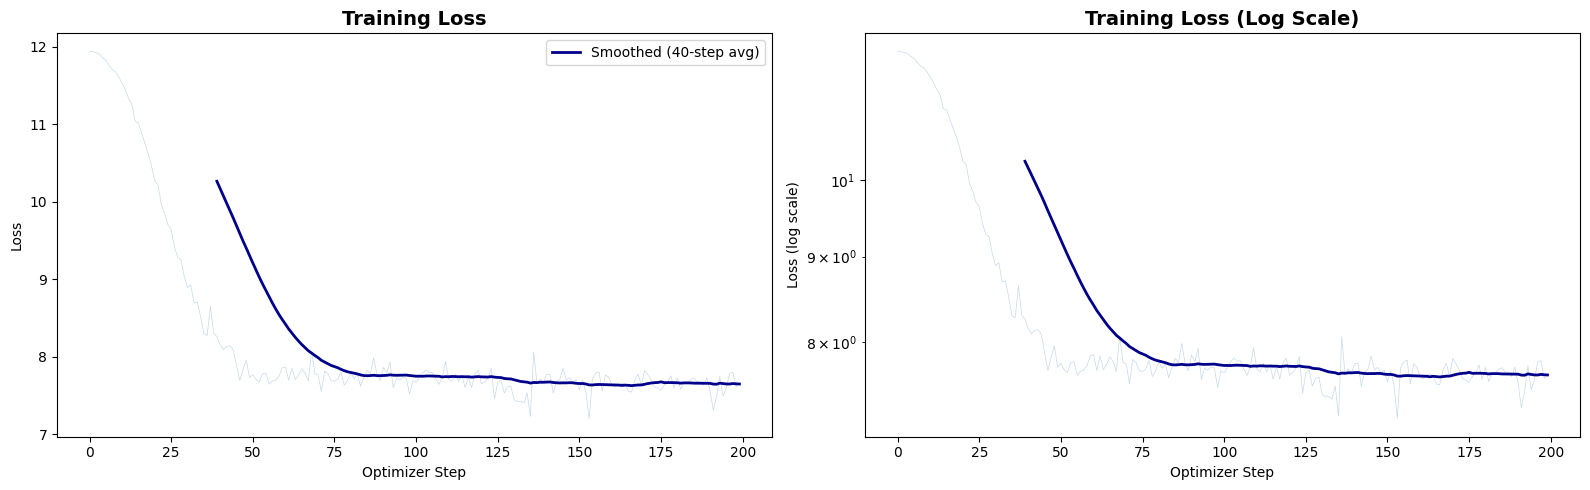

Initial loss:    11.9346
Final loss:      7.6501
Best loss:       7.2016 (step 154)
Random baseline: 11.9312 (ln(151,936))


In [13]:
if loss_history:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

    # Raw loss
    ax1.plot(loss_history, alpha=0.3, color='steelblue', linewidth=0.5)
    window = min(50, max(len(loss_history) // 5, 1))
    if window > 1:
        smoothed = np.convolve(loss_history, np.ones(window)/window, mode='valid')
        ax1.plot(range(window-1, len(loss_history)), smoothed,
                 color='darkblue', linewidth=2, label=f'Smoothed ({window}-step avg)')
    ax1.set_xlabel('Optimizer Step')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training Loss', fontsize=14, fontweight='bold')
    ax1.legend()

    # Log scale
    ax2.plot(loss_history, alpha=0.3, color='steelblue', linewidth=0.5)
    if window > 1:
        ax2.plot(range(window-1, len(loss_history)), smoothed,
                 color='darkblue', linewidth=2)
    ax2.set_yscale('log')
    ax2.set_xlabel('Optimizer Step')
    ax2.set_ylabel('Loss (log scale)')
    ax2.set_title('Training Loss (Log Scale)', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()

    random_loss = math.log(model_config.vocab_size)
    print(f'Initial loss:    {loss_history[0]:.4f}')
    print(f'Final loss:      {loss_history[-1]:.4f}')
    print(f'Best loss:       {min(loss_history):.4f} (step {np.argmin(loss_history) + 1})')
    print(f'Random baseline: {random_loss:.4f} (ln({model_config.vocab_size:,}))')
else:
    print('No training history yet. Run the training loop first.')

---
# Evaluation: Test on Unseen Data

> This uses the `evaluate` function from our package. It runs the model on data
> it has never trained on to check for overfitting.

In [14]:
# Use the validation split of the same dataset
# (StreamingTokenDataset defaults to 'train', so we create a quick val loader)
from datasets import load_dataset as _load_dataset
from torch.utils.data import IterableDataset

class ValDataset(IterableDataset):
    """Quick validation dataset — streams a different split."""
    def __init__(self, tokenizer, seq_len, n_chunks=50):
        self.tokenizer = tokenizer
        self.seq_len = seq_len
        self.n_chunks = n_chunks

    def __iter__(self):
        ds = _load_dataset('HuggingFaceFW/fineweb-edu', split='train', streaming=True)
        ds = ds.skip(100_000)  # skip past training data
        buffer = []
        yielded = 0
        for example in ds:
            tokens = self.tokenizer.encode(example['text'], add_special_tokens=False)
            tokens.append(self.tokenizer.eos_token_id)
            buffer.extend(tokens)
            while len(buffer) >= self.seq_len + 1:
                chunk = buffer[:self.seq_len + 1]
                buffer = buffer[self.seq_len + 1:]
                yield (torch.tensor(chunk[:-1], dtype=torch.long),
                       torch.tensor(chunk[1:], dtype=torch.long))
                yielded += 1
                if yielded >= self.n_chunks:
                    return

val_dataset = ValDataset(tokenizer, train_cfg.seq_len, n_chunks=50)
val_loader = DataLoader(val_dataset, batch_size=1)

val_loss = evaluate(model, val_loader, DEVICE, max_batches=50)
train_loss_final = loss_history[-1] if loss_history else float('nan')

print(f'Training loss (final step): {train_loss_final:.4f}')
print(f'Validation loss:            {val_loss:.4f}')
print()
if loss_history:
    gap = val_loss - train_loss_final
    if gap < 0.5:
        print('Train and val loss are close -> model is generalizing well.')
    elif gap < 2.0:
        print('Some gap between train and val -> mild overfitting (normal for small runs).')
    else:
        print('Large gap -> model may be overfitting. Consider more data or regularization.')

Resolving data files:   0%|          | 0/2410 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/2410 [00:00<?, ?it/s]

Training loss (final step): 7.6501
Validation loss:            7.4017

Train and val loss are close -> model is generalizing well.


---
# Sample Generations

> Let's see what the model actually outputs after training.

In [15]:
prompts = [
    'The most important thing about mathematics is',
    'In computer science, algorithms are',
    'Once upon a time',
]

for prompt in prompts:
    output = generate_sample(model, tokenizer, prompt, max_new_tokens=80)
    print(f'Prompt: "{prompt}"')
    print(f'Output: {output}')
    print()

Prompt: "The most important thing about mathematics is"
Output: The most important thing about mathematics is the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the

Prompt: "In computer science, algorithms are"
Output: In computer science, algorithms are the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the

Prompt: "Once upon a time"
Output: Once upon a time,,,,,,,,,,,,,,, the the the the the the the the the the the the the the the the the the the the the the the

---
# Compare Snapshots

> How much did the weights actually change during training?
> Compare the untrained snapshot with the post-training snapshot.

In [16]:
snapshot_files = sorted([f for f in os.listdir(train_cfg.snapshot_dir) if f.endswith('.pt')])
print('Saved snapshots:')
for f in snapshot_files:
    print(f'  {f}')

if 'pre-train-start.pt' in snapshot_files and len(snapshot_files) > 1:
    latest = [f for f in snapshot_files if f != 'pre-train-start.pt'][-1]
    snap_before = torch.load(os.path.join(train_cfg.snapshot_dir, 'pre-train-start.pt'), weights_only=False)
    snap_after  = torch.load(os.path.join(train_cfg.snapshot_dir, latest), weights_only=False)

    params = list(snap_before.keys())
    std_changes = [abs(snap_after[p]['std'] - snap_before[p]['std']) for p in params]
    mean_changes = [abs(snap_after[p]['mean'] - snap_before[p]['mean']) for p in params]

    print(f'\nComparing: pre-train-start.pt vs {latest}')
    print(f'  Avg |delta std|:  {np.mean(std_changes):.6f}')
    print(f'  Avg |delta mean|: {np.mean(mean_changes):.6f}')
    print(f'  Max |delta std|:  {np.max(std_changes):.6f}')
    print()
    print('For full visual comparison, open notebook 03 or 04.')
else:
    print('\nNeed at least 2 snapshots to compare. Run training first.')

Saved snapshots:
  pre-train-start.pt
  pre-trained.pt
  step_100.pt
  step_200.pt
  untrained-init.pt
  untrained.pt

Comparing: pre-train-start.pt vs untrained.pt
  Avg |delta std|:  0.008825
  Avg |delta mean|: 0.000017
  Max |delta std|:  0.899782

For full visual comparison, open notebook 03 or 04.


---
# What I Learned

### The 4 Essential Training Components

| Component | Function in `src/` | What It Does |
|-----------|-------------------|---------------|
| **Loss** | `compute_loss()` | Cross-entropy between predictions and true next tokens |
| **Optimizer** | `create_optimizer()` | AdamW with weight-decay groups (decay matrices, not norms) |
| **Scheduler** | `create_scheduler()` | Cosine LR with warmup (ramp up, then decay) |
| **Evaluation** | `evaluate()` | Val loss on unseen data (detects overfitting) |

### Key Takeaways

1. **The entire pre-training objective is next-token prediction.** Given tokens 1..N, predict N+1. Cross-entropy loss measures how wrong you are. Everything about language emerges from this single objective.

2. **Loss is your compass.** Random baseline is ln(vocab_size) ~ 11.9. Watch it drop. If it goes up, something is wrong (LR too high, data issue, bug).

3. **Weight decay is selective.** Big weight matrices get decay (prevents overfitting). Small norm/bias params don't (decaying them hurts training).

4. **Warmup prevents early chaos.** Random weights + large learning rate = explosion. Warmup ramps LR gently so weights stabilize first.

5. **Validation loss detects memorization.** If train loss drops but val loss rises, the model is memorizing rather than learning. More data or more regularization helps.

6. **Gradient accumulation is a memory trick.** Can't fit batch_size=32? Use batch_size=1 and accumulate 32 times. Same gradients, less memory.

7. **The `src/` package now has everything needed for training.** Config, model, data, loss, optimizer, scheduler, evaluation, checkpointing, generation — all reusable.

### Package Status After This Notebook

```
src/
├── config.py       ✓ CoreConfig (architecture settings)
├── core.py         ✓ CoreBlock (base class, weight init, freeze/unfreeze)
├── layers/         ✓ RMSNorm, RoPE, SwiGLU, GQAttention, FeedForward
├── models/         ✓ RQwen3 (full model with proper init)
├── data.py         ✓ StreamingTokenDataset (streaming + chunking)
├── training.py     ✓ TrainConfig, create_optimizer, create_scheduler,
│                     compute_loss, evaluate, save/load checkpoint,
│                     save_snapshot, generate_sample
├── tokenizers.py   ✓ ModelTokenizer wrapper
├── pipeline.py     ✓ PipeLine (tokenize → model → decode)
└── utils.py        ✓ get_device, print_model_summary, format_param_count
```

### Next Steps
- [ ] Run the Mac test (~200 steps) to verify the pipeline works
- [ ] Move to desktop (CUDA) for real training (10k+ steps)
- [ ] Re-run notebook 03/04 to see how weights changed
- [ ] **Notebook 06: SFT** — fine-tune on instruction data
- [ ] Process and organize training data back in RQwen3.ipynb